## USA Housing Regression Models + Feature Importance Analysis
This notebook compares multiple regression models and visualizes feature importance using a Random Forest model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [14]:
df = pd.read_csv("USA_Housing.csv")

# Drop non-numeric column
if "Address" in df.columns:
    df = df.drop("Address", axis=1)

X = df.drop("Price", axis=1)
y = df["Price"]
df.head

<bound method NDFrame.head of       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  
0            

In [ ]:
df = df.drop_duplicates()

print("Missing values BEFORE:\n", df.isnull().sum())

df = df.fillna(df.mean(numeric_only=True))

print("\nMissing values AFTER:\n", df.isnull().sum())
print("\nDataset shape after cleaning:", df.shape)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

Linear Regression R²: 0.9179971706834602
MAE: 80879.09723486962


In [8]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge R²:", r2_score(y_test, ridge.predict(X_test)))

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
print("Lasso R²:", r2_score(y_test, lasso.predict(X_test)))

en = ElasticNet(alpha=0.1, l1_ratio=0.5)
en.fit(X_train, y_train)
print("ElasticNet R²:", r2_score(y_test, en.predict(X_test)))

Ridge R²: 0.9179914220241199
Lasso R²: 0.9179971608478139
ElasticNet R²: 0.91608826344027


In [9]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

Random Forest R²: 0.8831663265656743
MAE: 94021.49260768459


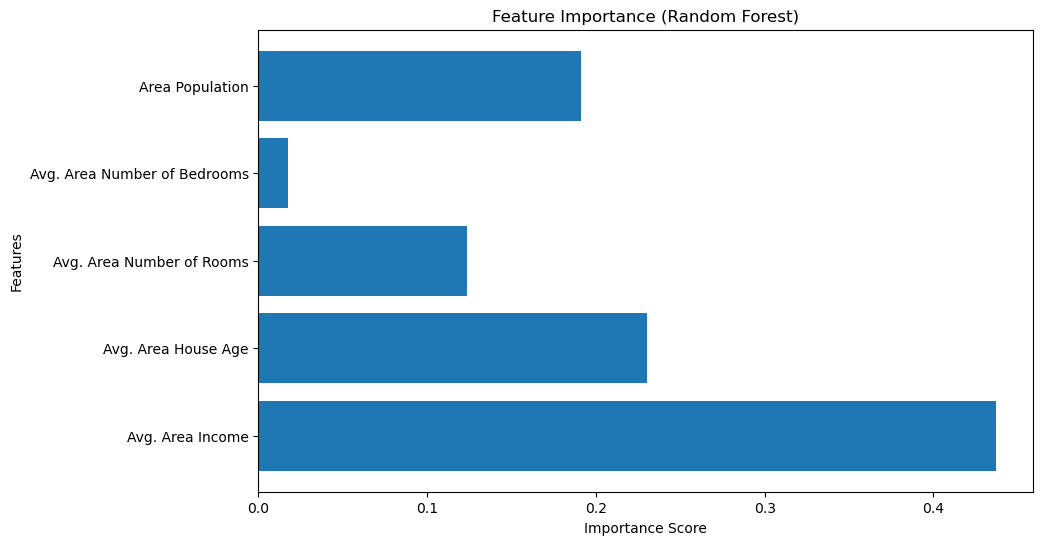

In [10]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Text(0.5, 1.0, 'Prediction vs Actual')

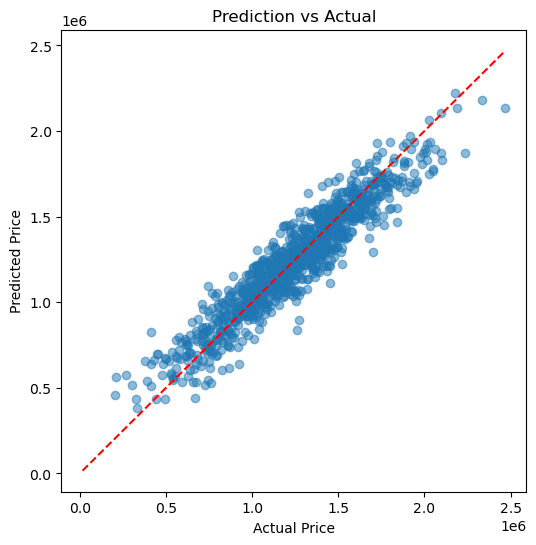

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction vs Actual")

In [13]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predictions
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print("📊 RANDOM FOREST PERFORMANCE")
print("----------------------------")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R² : {test_r2:.4f}")
print(f"Training MAE: {train_mae:,.2f}")
print(f"Testing MAE : {test_mae:,.2f}")

📊 RANDOM FOREST PERFORMANCE
----------------------------
Training R²: 0.9842
Testing R² : 0.8832
Training MAE: 35,293.65
Testing MAE : 94,021.49
